<h2 align='center' style='color:blue'>Exercise: Outlier removal using standard deviation and z score<h2>

You are given bhp.csv which contains property prices in the city of banglore, India. You need to examine price_per_sqft column and do following,

(1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, you get a new dataframe.

(3) On step(2) dataframe, use 4 standard deviation to remove outliers

(4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram

(5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [1]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

In [2]:
df = pd.read_csv("/content/sample_data/bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


We will quickly examine price_per_sqft column to check min,max,mean and percentile values

In [3]:
df.price_per_sqft.describe()

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


Above, you can see max is 12000000, which is too much price for price per sqft. Looks like this dataset has some very bad outliers so we will first remove those with percentile and then use z score

In [4]:
df.total_sqft.describe()

,total_sqft
count,13200.000000
mean,1555.302783
std,1237.323445
min,1.000000
25%,1100.000000
50%,1275.000000
75%,1672.000000
max,52272.000000


Also **plot histogram** to see how is the data distribution

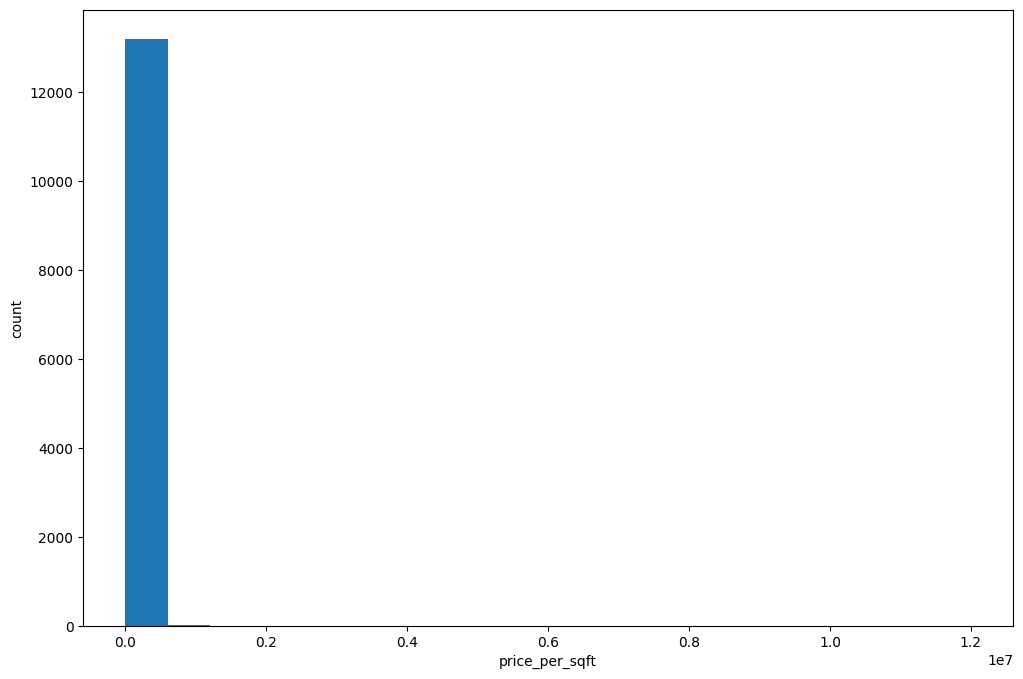

In [9]:
# %matplotlib inline
plt.hist(df.price_per_sqft, bins=20)
plt.xlabel('price_per_sqft')
plt.ylabel('count')
plt.show()
      #  plt.scatter(df.price_per_sqft,df.count,color='green',marker="*")


Above chart confirms our understanding that this dataset has some bad outliers. Because we see only one bar with more than 12000 data points but on the right hand side there are data points that have higher value for price per sqft but count of these data points is very tiny compared to 12000 hence we can hardly see any bar

Using **log scale** can make visualization little better

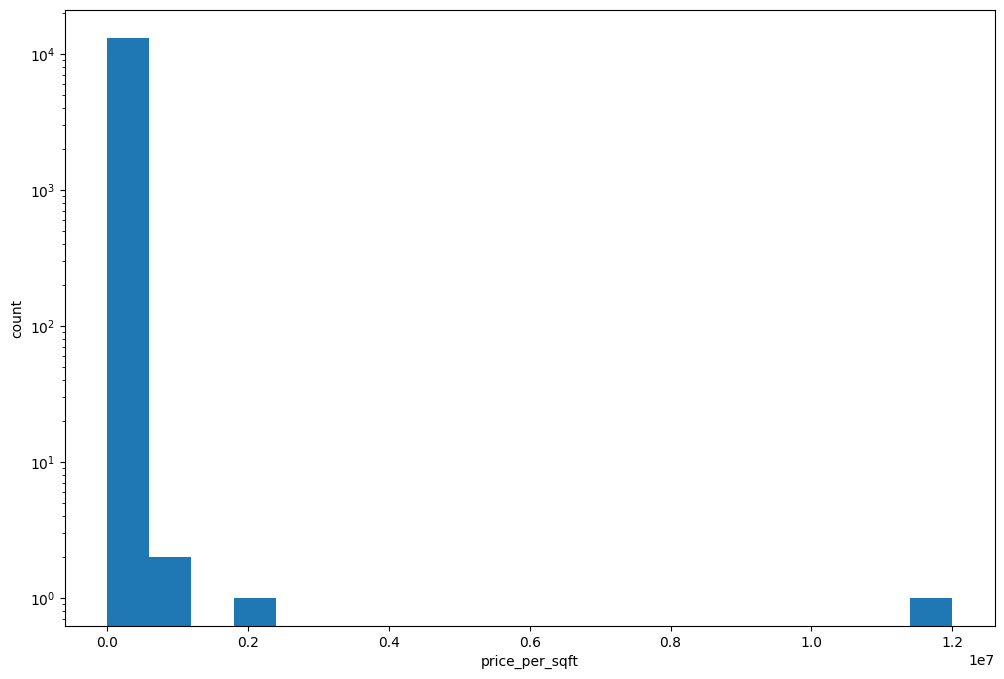

In [13]:
plt.hist(df.price_per_sqft, bins=20)
plt.xlabel('price_per_sqft')
plt.ylabel("count")
plt.yscale("log")# it converts the y scale to logarithm value
plt.show()

You see atleast few bars on right hand side of our highest building at least :)

<h3 style='color:purple'>(1) Treat outliers using percentile first</h3>

In [17]:
lower_limit, upper_limit = df.price_per_sqft.quantile([0.001,0.999])
lower_limit,upper_limit

(1366.184, 50959.36200000098)

In [23]:
df2= df[(df.price_per_sqft>=lower_limit) &
 (df.price_per_sqft<=upper_limit)]

Above shows properties that has price_per_sqft value such as 500 rs which is very very low for the city of banglore. You would be very lucky if you can find such as property :)
Also we have properties that has price per sqft value such as 12000000 which is way too high. It seems almost impossible and even if it is legitimate it can help data analysis process if we remove such a data point

In [21]:
df["price_per_sqft"].dtype

dtype('int64')

In [24]:
df2.shape

(13172, 7)

In [ ]:
df.shape

(13200, 7)

In [25]:
13200-13172

28

**We removed total 28 outliers**

<h3 style='color:purple'>(2) Now remove outliers using 4 standard deviation</h3>

In [29]:
mean=df2.price_per_sqft.mean()
std=df2.price_per_sqft.std()
print(mean,std)

6663.6537351958705 4141.020700174605


In [47]:
df3 = df2[
    (df2.price_per_sqft >= lower_limit) &
    (df2.price_per_sqft <= upper_limit)
]
# df2.price_per_sqft >= lower_limit &
# df2.price_per_sqft <= upper_limit

In [48]:
df3.shape


(13172, 7)

In [49]:
df3

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [42]:
df2.shape

(13172, 7)

In [39]:
13172-13047

125

In this step we removed total 125 outliers

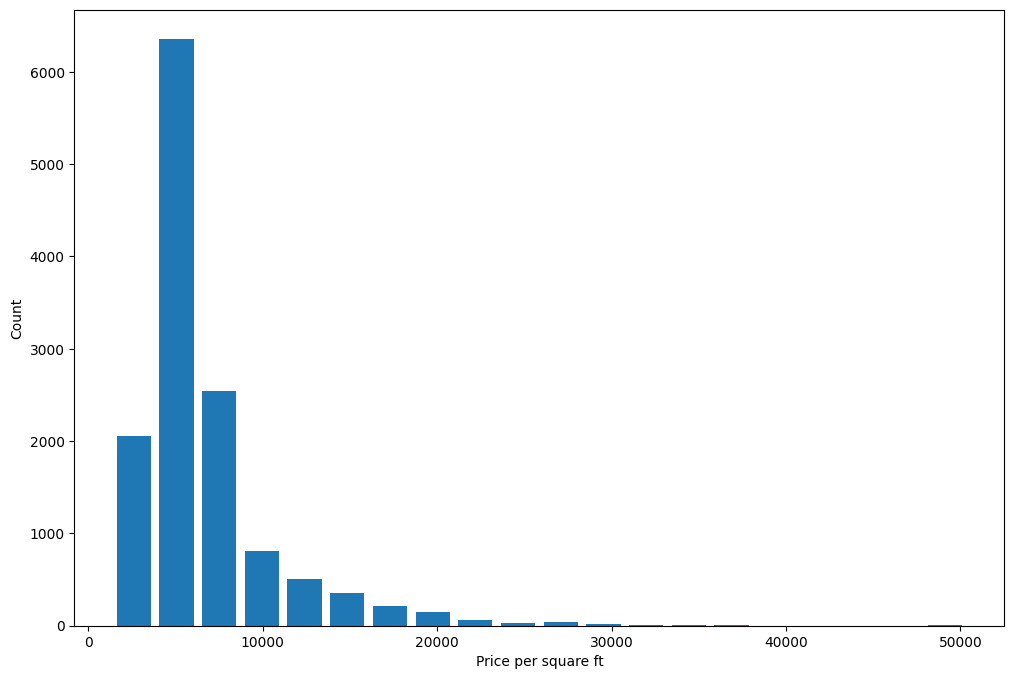

In [50]:
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel("Price per square ft")
plt.ylabel("Count")
plt.show()

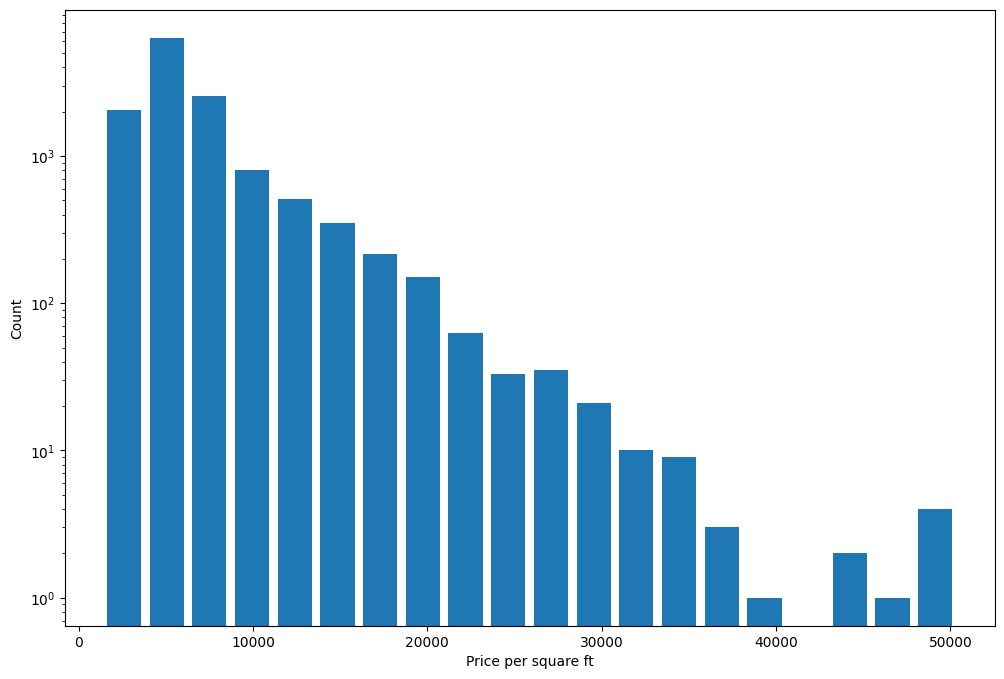

In [51]:
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel("Price per square ft")
plt.ylabel("Count")
plt.yscale("log")
plt.show()

In [52]:
from scipy.stats import zscore

<h3 style='color:purple'>(3) Now remove outliers using z score. Use z score of 4 as your thresold</h3>

In [53]:
df2['zscore']=zscore(df2.price_per_sqft)
df2.head()

/tmp/ipykernel_1169/2807894146.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zscore']=zscore(df2.price_per_sqft)


,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.715951
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.494741
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.569604
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.101103
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.582887


In [54]:
df2[df2.zscore >4]

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274,7.150766
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333,6.440528
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083,4.931181
733,Cunningham Road,4 BHK,5270.0,4.0,1250.0,4,23719,4.118790
760,other,9 Bedroom,600.0,9.0,190.0,9,31666,6.037955
...,...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000,6.843101
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.931181
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.931181
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000,9.016560


,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
3136,other,4 Bedroom,1200.0,4.0,350.0,4,29166,5.434010
6134,Basavangudi,6 Bedroom,1754.0,6.0,650.0,6,37058,7.339820
9099,Whitefield,3 BHK,1496.0,2.0,718.0,3,47994,9.980715
3675,Kasturi Nagar,5 Bedroom,1650.0,5.0,450.0,5,27272,4.976634
9360,HAL 2nd Stage,4 Bedroom,2280.0,4.0,615.0,4,26973,4.904430


In [55]:
df2[df2.zscore < -4]
df4 = df2[(df2.zscore > -4) & (df2.zscore < 4)]
df4.shape

(13047, 8)

In [56]:
13172-13047

125

In this step also we removed 125 outliers. The result would be exactly same as 4 standard deviation